# Synthetic-n recoverability — arm 1 (`distributed`) vs Leopold-Maddock truth

Generated 2026-07-29 by the ddrs-eval-plots skill.

**Inputs**
- Truth donor: `output/synthetic_n/truth_leopold_maddock.nc` (prescribed n + consensus geometry)
- Recovered:   `output/synthetic_n/recovered_distributed.nc` (student checkpoint `.ddrs-synthetic-n-distributed/runs/2026-07-28T16-12-57Z-train-and-test/checkpoints/epoch_5_mb_35`, trained on the aorc2f distributed Q' store against synthetic obs)
- Attributes:  `~/projects/ddr/data/merit_global_attributes_v2.nc` (`log10_uparea`)
- Fabric:      `~/projects/ddr/data/merit/cat_pfaf_7_MERIT_Hydro_v07_Basins_v01_bugfix1.shp`

**Caveat:** arm 1 of 4 — S1–S5 verdicts require all arms. Preview only.

In [1]:
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from mpl_toolkits.axes_grid1 import make_axes_locatable

REPO = Path("/home/tbindas/projects/ddrs")
OUT = REPO / "output/synthetic_n"
PLOT_DIR = OUT / "plots"
PLOT_DIR.mkdir(exist_ok=True)
ATTRS_NC = Path("/home/tbindas/projects/ddr/data/merit_global_attributes_v2.nc")
SHAPEFILE = Path("/home/tbindas/projects/ddr/data/merit/cat_pfaf_7_MERIT_Hydro_v07_Basins_v01_bugfix1.shp")
ARM = "distributed"

truth = xr.open_dataset(OUT / "truth_leopold_maddock.nc")
tc = truth["COMID"].values
rec = xr.open_dataset(OUT / f"recovered_{ARM}.nc").set_index(COMID="COMID").sel(COMID=tc)
attrs = xr.open_dataset(ATTRS_NC).set_index(COMID="COMID").sel(COMID=tc)
lup = attrs["log10_uparea"].values.astype(np.float64)
tn, rn = truth["n"].values, rec["n"].values
print(f"{len(tc):,} COMIDs aligned")

346,321 COMIDs aligned


saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/n_recovery_hexbin_distributed.png


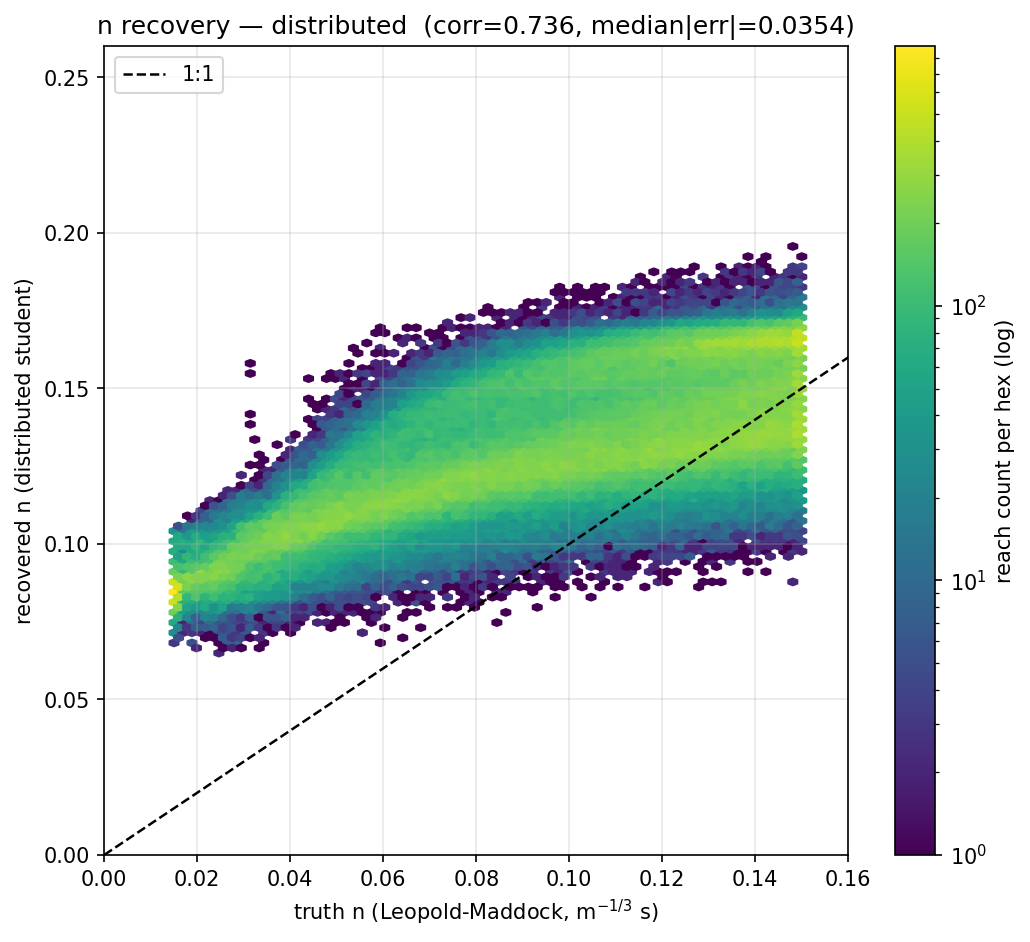

In [2]:
# --- Recovery hexbin: truth n vs recovered n -------------------------------
corr = np.corrcoef(tn, rn)[0, 1]
mae = np.median(np.abs(rn - tn))
fig, ax = plt.subplots(figsize=(8, 7), dpi=150)
hb = ax.hexbin(tn, rn, gridsize=70, cmap="viridis", mincnt=1, bins="log")
fig.colorbar(hb, ax=ax, label="reach count per hex (log)")
lims = (0.0, 0.26)
ax.plot(lims, lims, "k--", lw=1.2, label="1:1")
ax.set_xlim(0.0, 0.16); ax.set_ylim(lims)
ax.set_xlabel("truth n (Leopold-Maddock, m$^{-1/3}$ s)")
ax.set_ylabel(f"recovered n ({ARM} student)")
ax.set_title(f"n recovery — {ARM}  (corr={corr:.3f}, median|err|={mae:.4f})")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
out = PLOT_DIR / f"n_recovery_hexbin_{ARM}.png"
fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
print(f"saved {out}")

saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/n_slope_vs_uparea_distributed.png


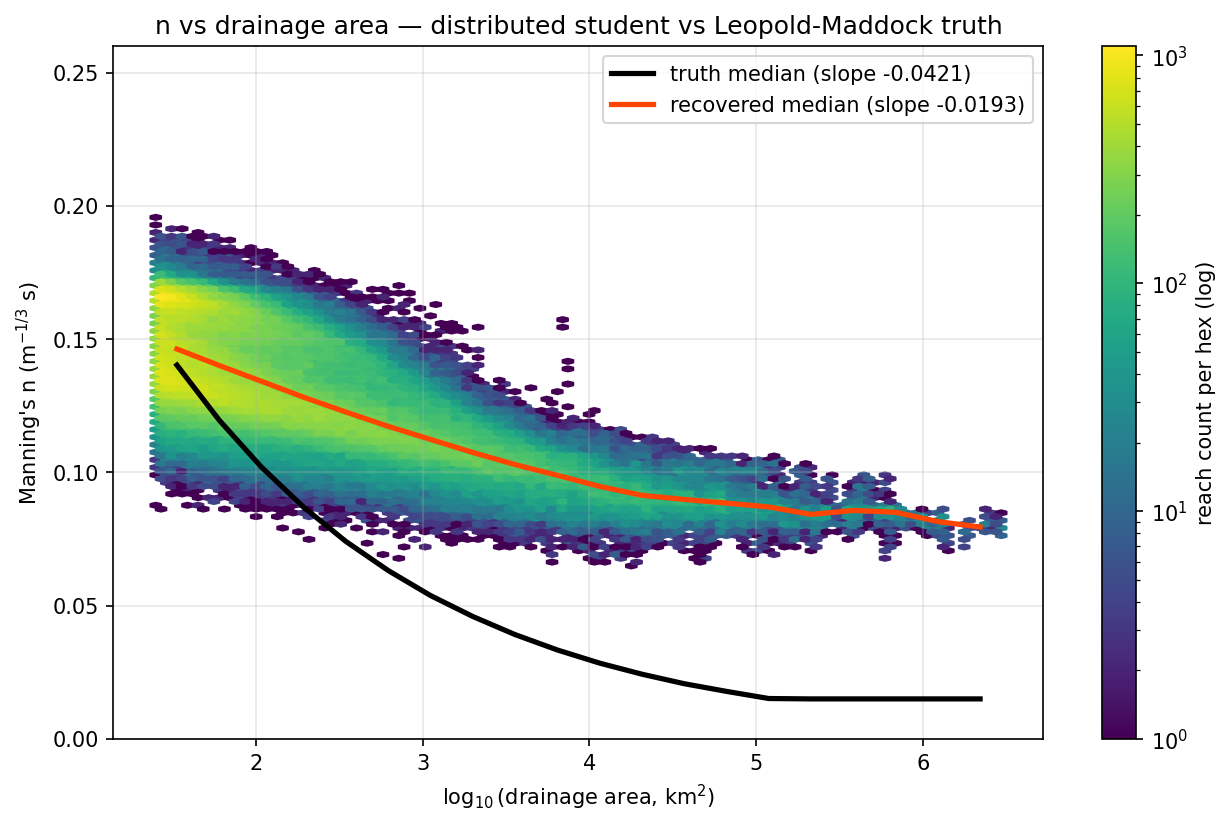

In [3]:
# --- n vs log10(uparea): the Leopold-Maddock slope test --------------------
t_slope, t_int = np.polyfit(lup, tn, 1)
r_slope, r_int = np.polyfit(lup, rn, 1)
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
hb = ax.hexbin(lup, rn, gridsize=80, cmap="viridis", mincnt=1, bins="log")
fig.colorbar(hb, ax=ax, label="reach count per hex (log)")
bin_edges = np.linspace(lup.min(), lup.max(), 21)
bin_idx = np.digitize(lup, bin_edges) - 1
bc = 0.5 * (bin_edges[:-1] + bin_edges[1:])
med_t = np.array([np.nanmedian(tn[bin_idx == b]) if np.any(bin_idx == b) else np.nan for b in range(20)])
med_r = np.array([np.nanmedian(rn[bin_idx == b]) if np.any(bin_idx == b) else np.nan for b in range(20)])
ax.plot(bc, med_t, color="black", lw=2.5, label=f"truth median (slope {t_slope:+.4f})")
ax.plot(bc, med_r, color="#ff4500", lw=2.5, label=f"recovered median (slope {r_slope:+.4f})")
ax.set_xlabel(r"$\log_{10}$(drainage area, km$^2$)")
ax.set_ylabel("Manning's n (m$^{-1/3}$ s)")
ax.set_ylim(0.0, 0.26)
ax.set_title(f"n vs drainage area — {ARM} student vs Leopold-Maddock truth")
ax.legend(loc="upper right", frameon=True)
ax.grid(alpha=0.3)
out = PLOT_DIR / f"n_slope_vs_uparea_{ARM}.png"
fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
print(f"saved {out}")

saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/n_hist_truth_vs_recovered_distributed.png


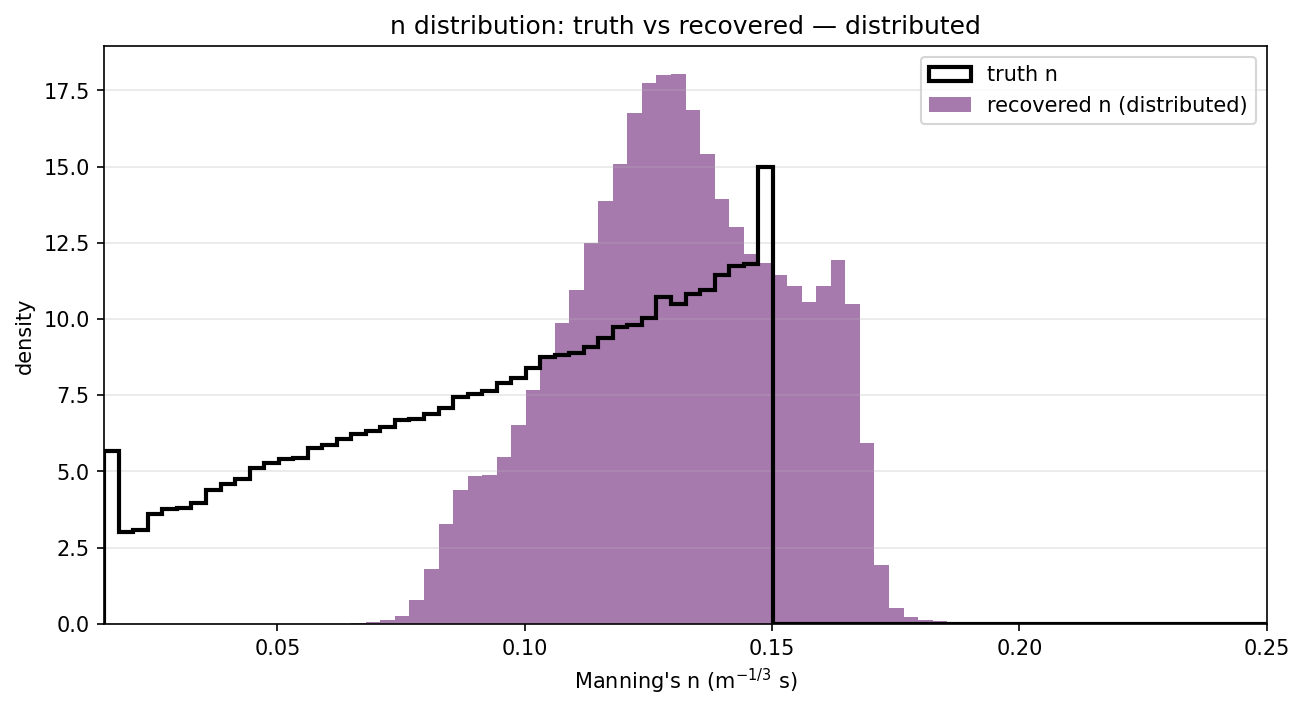

In [4]:
# --- Distribution overlay (x-axis anchored to YAML range [0.015, 0.25]) ----
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.hist(tn, bins=80, range=(0.015, 0.25), color="black", histtype="step", lw=2, label="truth n", density=True)
ax.hist(rn, bins=80, range=(0.015, 0.25), color="#6c2178", alpha=0.6, label=f"recovered n ({ARM})", density=True)
ax.set_xlim(0.015, 0.25)
ax.set_xlabel("Manning's n (m$^{-1/3}$ s)")
ax.set_ylabel("density")
ax.set_title(f"n distribution: truth vs recovered — {ARM}")
ax.legend(); ax.grid(axis="y", alpha=0.3)
out = PLOT_DIR / f"n_hist_truth_vs_recovered_{ARM}.png"
fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
print(f"saved {out}")

saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/geometry_recovery_distributed.png


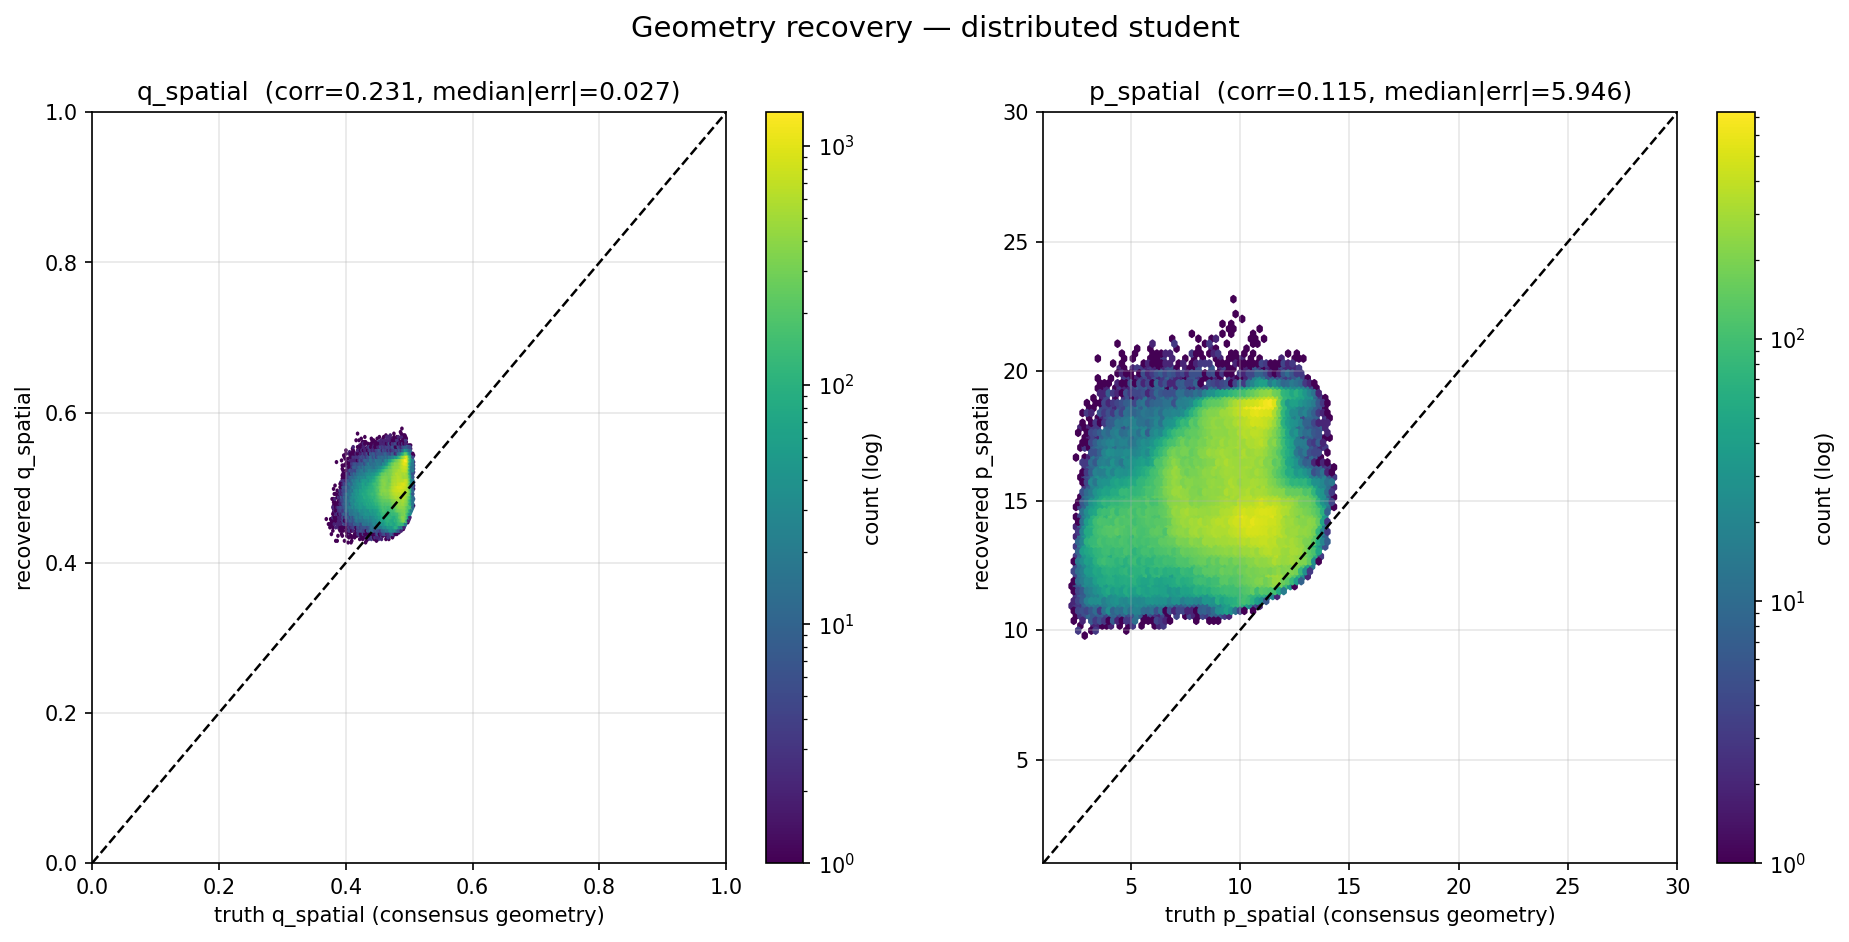

In [5]:
# --- Geometry recovery: q_spatial and p_spatial ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=150)
for ax, var, rng in zip(axes, ["q_spatial", "p_spatial"], [(0.0, 1.0), (1.0, 30.0)]):
    tv, rv = truth[var].values, rec[var].values
    c = np.corrcoef(tv, rv)[0, 1]
    m = np.median(np.abs(rv - tv))
    hb = ax.hexbin(tv, rv, gridsize=60, cmap="viridis", mincnt=1, bins="log")
    fig.colorbar(hb, ax=ax, label="count (log)")
    ax.plot(rng, rng, "k--", lw=1.2)
    ax.set_xlim(rng); ax.set_ylim(rng)
    ax.set_xlabel(f"truth {var} (consensus geometry)")
    ax.set_ylabel(f"recovered {var}")
    ax.set_title(f"{var}  (corr={c:.3f}, median|err|={m:.3f})")
    ax.grid(alpha=0.3)
fig.suptitle(f"Geometry recovery — {ARM} student", fontsize=14)
out = PLOT_DIR / f"geometry_recovery_{ARM}.png"
fig.savefig(out, dpi=300, bbox_inches="tight", facecolor="white")
print(f"saved {out}")

In [6]:
# --- Spatial maps: truth n, recovered n, signed error (CONUS) --------------
gdf = gpd.read_file(SHAPEFILE).set_index("COMID")
shared = np.intersect1d(gdf.index.values, tc)
print(f"shapefile join: {len(shared):,} COMIDs")
n_t = pd.Series(tn, index=tc).reindex(gdf.index)
n_r = pd.Series(rn, index=tc).reindex(gdf.index)
gdf["n_truth"] = n_t.values
gdf["n_rec"] = n_r.values
gdf["n_err"] = (n_r - n_t).values
gdf = gdf.set_crs(epsg=4326)
BBOX = (-125, 24, -66, 53)

def n_map(col, title, cmap, vmin, vmax, fname, center=False):
    g = gdf.dropna(subset=[col]).sort_values(col if not center else col, key=(np.abs if center else None))
    fig, ax = plt.subplots(figsize=(12, 7), dpi=150)
    g.plot(ax=ax, column=col, cmap=cmap, linewidth=0.3, vmin=vmin, vmax=vmax, zorder=1)
    try:
        import contextily as cx
        cx.add_basemap(ax, crs=g.crs, source=cx.providers.CartoDB.Positron, alpha=0.6, zorder=0, attribution=False)
    except Exception as e:
        print(f"basemap skipped ({type(e).__name__})"); ax.set_facecolor("#f0f0f0")
    ax.set_xlim(BBOX[0], BBOX[2]); ax.set_ylim(BBOX[1], BBOX[3])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=14)
    cax = make_axes_locatable(ax).append_axes("right", size="3%", pad=0.1)
    sm = plt.cm.ScalarMappable(cmap=cmap); sm.set_array([]); sm.set_clim(vmin, vmax)
    fig.colorbar(sm, cax=cax).set_label("n (m$^{-1/3}$ s)" if not center else "recovered − truth n")
    fig.savefig(PLOT_DIR / fname, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    print(f"saved {PLOT_DIR / fname}")

n_map("n_truth", "Truth n (Leopold-Maddock) — CONUS", "plasma_r", 0.015, 0.15, "map_n_truth_conus.png")
n_map("n_rec", f"Recovered n ({ARM} student) — CONUS", "plasma_r", 0.015, 0.15, f"map_n_recovered_{ARM}_conus.png")
n_map("n_err", f"n error (recovered − truth), {ARM} — CONUS", "RdBu_r", -0.08, 0.08, f"map_n_error_{ARM}_conus.png", center=True)

shapefile join: 346,321 COMIDs


saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/map_n_truth_conus.png


saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/map_n_recovered_distributed_conus.png


saved /home/tbindas/projects/ddrs/output/synthetic_n/plots/map_n_error_distributed_conus.png
